In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import sys
sys.path.append("/home/iscb/wolfson/hagairavid/ligand_alligner")
from utils.constants import NOT_ENOUGH_ATOMS_MESSAGE, TOO_MUCH_RESIDUES_MESSAGE, LIGAND_RESIDUE_IS_MISSED_MESSAGE, N_ATOMS_RATIO_MESSAGE


In [37]:
prefix = "2024-05-16_13-21-05"
directory = "/home/iscb/wolfson/hagairavid/ligand_alligner/temp_results/"
matching_files = [f for f in os.listdir(directory) if f.startswith(prefix)]

if matching_files:
    latest_file = max(matching_files, key=lambda x: os.path.getmtime(os.path.join(directory, x)))
    file_path = os.path.join(directory, latest_file)
    print("Latest file:", file_path)
else:
    print("No matching files found.")
df = pd.read_csv(file_path)


df['coverage'] = df['coverage'].astype(str)
df['rmse'] = df['rmse'].astype(str)

def str_to_list_of_lists(s):
    try:
        tuple_of_lists = ast.literal_eval(s)
        list_of_lists = [list(sublist) for sublist in tuple_of_lists]
        return list_of_lists
    except:
        return []

df['coverage'] = df['coverage'].apply(str_to_list_of_lists)
df['rmse'] = df['rmse'].apply(str_to_list_of_lists)
df.head()


Latest file: /home/iscb/wolfson/hagairavid/ligand_alligner/temp_results/2024-05-16_13-21-05_1717.csv


,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
0,SAH,3cjt,5w7k,A,A,1.0,"([array([[-5.9455436e-01, 3.9775431e-01, -6.9...","([[...]],)",[[0.22866011181638066]],[[0.8846153846153846]],0,[26],[26],NaN
1,SAH,5log,5xoh,A,A,2.0,"([array([[-0.3653756 , 0.91272116, -0.1828681...","([[...]],)","[[0.22668009604250278, 0.05751939637599506]]","[[0.38461538461538464, 0.4230769230769231]]",4,[26],[26],NaN
2,SAH,3lby,7ux7,A,A,1.0,"([array([[ 0.6084582 , -0.54846615, -0.5735534...","([[...]],)",[[0.1100818278401382]],[[0.46153846153846156]],0,[26],[26],NaN
3,SAH,3g2p,4cng,A,A,3.0,"([array([[ 0.6009561 , 0.78257763, -0.1625545...","([[...], [...]], [[...], [...]])","[[0.12162848537163626], [0.1853473335943481, 0...","[[0.46153846153846156], [0.46153846153846156, ...",2,[26],"[26, 26]",NaN
4,SAH,5bxy,7qos,A,A,1.0,"([array([[-0.20931455, 0.18244344, 0.9606777...","([[...]],)",[[0.2888605678319815]],[[0.8076923076923077]],0,[26],[26],NaN


## Number of transformations

Text(0.5, 1.0, 'Number of transformations')

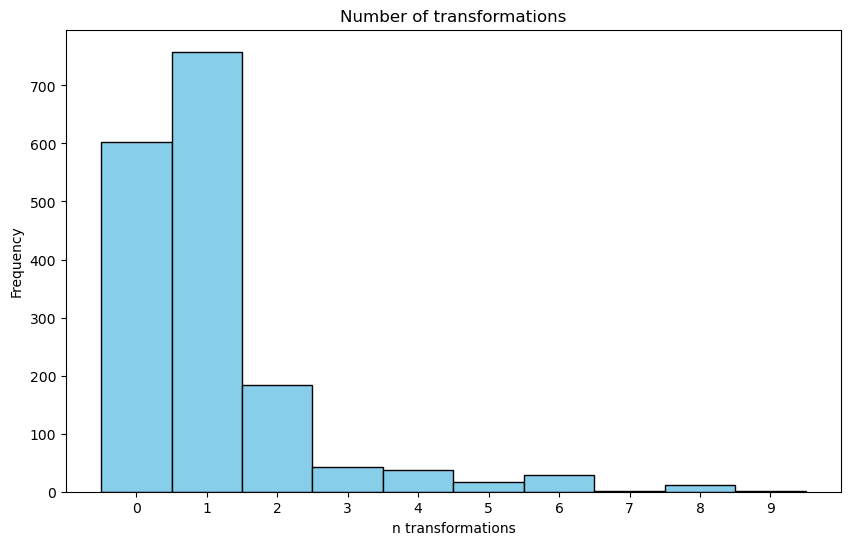

In [38]:
filtered_df = df[df['n_transformations'] < 10]
plt.figure(figsize=(10, 6))
plt.hist(filtered_df['n_transformations'], bins= int(filtered_df['n_transformations'].max()) + 1, range=(0-0.5, filtered_df['n_transformations'].max()+0.5), color='skyblue', edgecolor='black')
plt.xticks(filtered_df['n_transformations'].unique())

# Adding labels and title

plt.xlabel('n transformations')
plt.ylabel('Frequency')
plt.title('Number of transformations')

#### Pairs with 2 clusters for specific ligand residues

In [39]:
def has_2_trans(values):
    for val in values:
        if len(val) == 2:
            return True
    return False

has_two_clusters = df['coverage'].apply(has_2_trans)
print(has_two_clusters.sum())
df[has_two_clusters].head()

47


,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
1,SAH,5log,5xoh,A,A,2.0,"([array([[-0.3653756 , 0.91272116, -0.1828681...","([[...]],)","[[0.22668009604250278, 0.05751939637599506]]","[[0.38461538461538464, 0.4230769230769231]]",4,[26],[26],NaN
3,SAH,3g2p,4cng,A,A,3.0,"([array([[ 0.6009561 , 0.78257763, -0.1625545...","([[...], [...]], [[...], [...]])","[[0.12162848537163626], [0.1853473335943481, 0...","[[0.46153846153846156], [0.46153846153846156, ...",2,[26],"[26, 26]",NaN
53,ADP,3mbi,8as8,A,A,2.0,"([array([[-0.66841686, 0.3253739 , -0.6688428...","([[...]],)","[[0.1155635012855361, 0.28491623454010784]]","[[0.4444444444444444, 0.3333333333333333]]",0,[27],[27],NaN
61,ADP,1htw,6rm8,A,A,2.0,"([array([[ 0.99929726, -0.01550836, 0.0341255...","([[...]],)","[[0.32824564045030813, 0.12495181722539181]]","[[0.4444444444444444, 0.4074074074074074]]",0,[27],[27],NaN
161,ATP,7tzc,8jxu,A,A,3.0,"([array([[-0.9699691 , -0.23779964, 0.0511015...","([[...], [...]], [[...], [...]])","[[0.004437108140220756], [0.20669997954678335,...","[[0.3548387096774194], [0.45161290322580644, 0...",0,"[31, 31]",[31],NaN


In [40]:
# filtered_df = df[df["failure message"].isna()]
df[df["n_transformations"] == 0]["failure message"].value_counts()
no_trans = df[df["n_transformations"] == 0]
print(no_trans[no_trans["failure message"].isna()].shape)
no_trans[no_trans["failure message"].isna()].head()

(54, 14)


,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
162,ATP,4xru,6msj,B,A,0.0,"([],)","([[...]],)",[[]],[[]],0,[31],[31],NaN
199,NAP,4nh4,7tcm,A,A,0.0,"([],)","([[...]],)",[[]],[[]],0,[48],[48],NaN
200,NAP,6t62,7y1u,A,A,0.0,"([],)","([[...]],)",[[]],[[]],0,[48],[48],NaN
201,NAP,1piw,6yc8,A,A,0.0,"([],)","([[...]],)",[[]],[[]],0,[48],[48],NaN
204,NAP,4ol9,7vr4,A,A,0.0,"([],)","([[...]],)",[[]],[[]],0,[48],[48],NaN


### Failres

/tmp/ipykernel_347574/1791104930.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['failure message'].dropna(), data=df, palette='viridis')


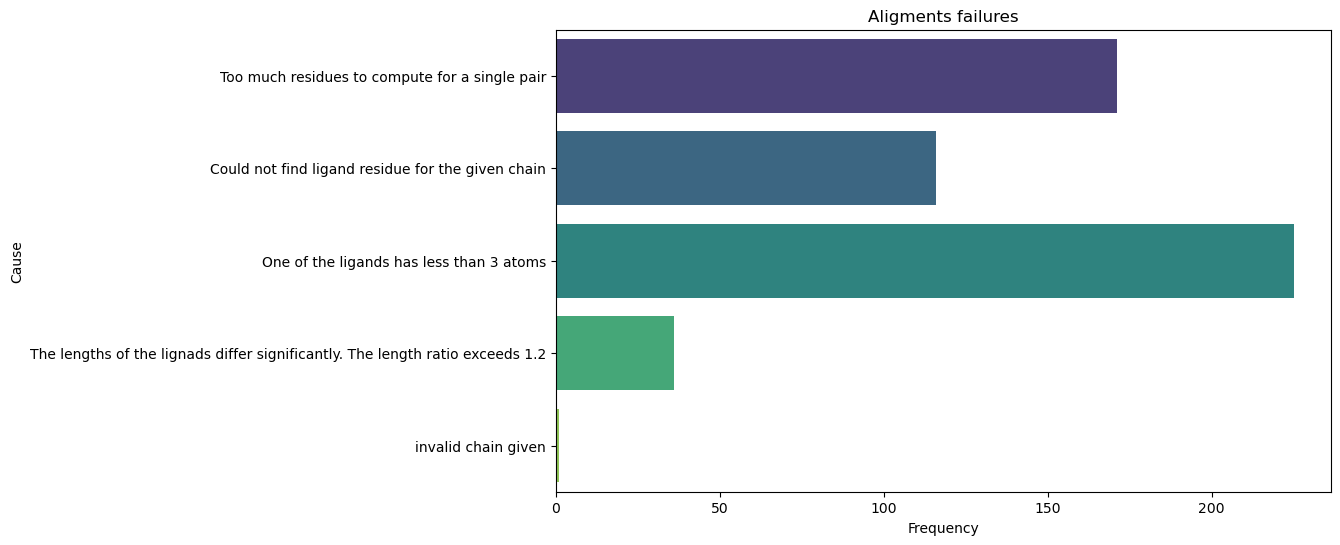

In [41]:
plt.figure(figsize=(10, 6)) 
sns.countplot(y=df['failure message'].dropna(), data=df, palette='viridis')
plt.xlabel('Frequency')
plt.ylabel('Cause')
plt.title('Aligments failures')
plt.show()

In [42]:
df[df['failure message'] == N_ATOMS_RATIO_MESSAGE].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
195,CNA,1a26,6hxs,A,A,0.0,(),(),[],[],0,[27],[44],The lengths of the lignads differ significantl...
212,NAP,5gsn,8u2w,A,A,0.0,(),(),[],[],0,[48],[31],The lengths of the lignads differ significantl...
385,COA,3f5o,7s3u,A,A,0.0,(),(),[],[],0,[38],[48],The lengths of the lignads differ significantl...
386,COA,5kf2,8p5s,A,A,0.0,(),(),[],[],0,[23],[31],The lengths of the lignads differ significantl...
388,COA,1y7u,6b3t,A,A,0.0,(),(),[],[],1,[48],[39],The lengths of the lignads differ significantl...


In [43]:
df[df['failure message'] == NOT_ENOUGH_ATOMS_MESSAGE].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
111,CO,2ew5,3s8k,A,A,0.0,(),(),[],[],0,[1],"[1, 1]",One of the ligands has less than 3 atoms
112,CO,2ywr,6cgy,A,A,0.0,(),(),[],[],1,"[1, 1, 1, 1]","[1, 1]",One of the ligands has less than 3 atoms
113,CO,2uzp,3n5f,A,A,0.0,(),(),[],[],0,[1],[1],One of the ligands has less than 3 atoms
114,CO,1gwm,7etl,A,A,0.0,(),(),[],[],0,[1],[1],One of the ligands has less than 3 atoms
115,CO,2os3,4wzx,A,A,0.0,(),(),[],[],0,[1],[1],One of the ligands has less than 3 atoms


In [44]:
df[df['failure message'] == LIGAND_RESIDUE_IS_MISSED_MESSAGE].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
64,HEM,1drm,1jju,A,B,0.0,(),(),[],[],0,[43],[],Could not find ligand residue for the given chain
84,NaN,3r0x,4zla,A,A,0.0,(),(),[],[],2,[],[],Could not find ligand residue for the given chain
85,NaN,1c9o,8hir,A,A,0.0,(),(),[],[],0,[],[],Could not find ligand residue for the given chain
86,NaN,3pak,4zla,A,A,0.0,(),(),[],[],1,[],[],Could not find ligand residue for the given chain
87,NaN,5nv9,8cv2,A,A,0.0,(),(),[],[],0,[],[],Could not find ligand residue for the given chain


In [45]:
df[df['failure message'] == TOO_MUCH_RESIDUES_MESSAGE].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
21,ASN,2dqn,6pa3,A,A,0.0,(),(),[],[],0,"[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",Too much residues to compute for a single pair
22,ASN,2cg4,6pa3,A,A,0.0,(),(),[],[],0,"[8, 8, 8, 8, 9]","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",Too much residues to compute for a single pair
23,ASN,3h0l,6pa3,A,A,0.0,(),(),[],[],0,"[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",Too much residues to compute for a single pair
24,ASN,11as,6ior,A,A,0.0,(),(),[],[],2,"[8, 8, 8, 9]","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9]",Too much residues to compute for a single pair
25,ASN,11as,3kxa,A,A,0.0,(),(),[],[],0,"[8, 8, 8, 9]","[8, 8, 8, 8, 8, 9]",Too much residues to compute for a single pair


## CATH analsys:


Text(0.5, 1.0, 'mean of (1-mse) + coverage')

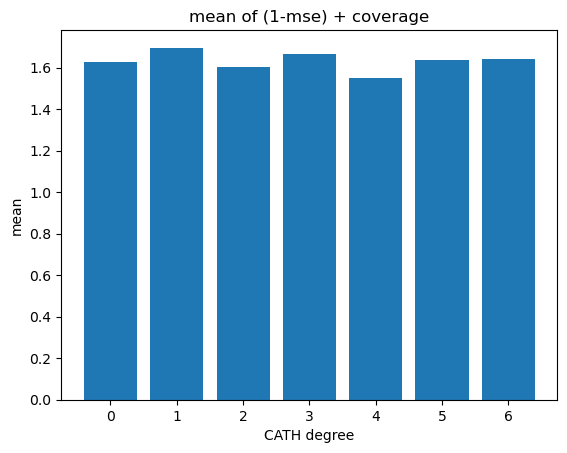

In [46]:

def sum_per_row(lst):
    return sum(lst)  if lst else None

def calculate_gap(row):
    ret = []
    for coverage, rmse in zip(row['coverage'], row['rmse']):
        for i in range(len(coverage)):
            ret.append(coverage[i] + (1- rmse[i]))
    return ret

df['gap'] = df.apply(calculate_gap, axis=1)
df['total_gap'] = df['gap'].apply(sum_per_row)
mean_values = df.groupby('cath_degree')['total_gap'].sum() / df.groupby('cath_degree')['n_transformations'].sum()

# Step 2: Create the histogram
plt.bar(mean_values.index, mean_values.values)
plt.xlabel('CATH degree')
plt.ylabel('mean')
plt.title('mean of (1-mse) + coverage')